# Ejercicio 2: Stencil 1D

<span style="color:green">Este ejercicio se ha completado de manera local usando una gráfica RTX 4060</span>

In [64]:
from numba import jit, njit, cuda
import numpy as np
import matplotlib.pyplot as plt
import typing
import time
import numba

In [65]:
class Timer:

    def __enter__(self):
        self.start = time.time()
        return self

    def __exit__(self, *args):
        self.end = time.time()
        self.interval = self.end - self.start


La versión que usaremos de stencil-1d es equivalente a la expuesta en las diapositivas, con la diferencia de que el "halo" añadido que usaremos serán ceros en vez de unos como se encuentra en el código de C (se puede observar como usa `fill_ints` para el padding). Sin añadir ese padding nuestra función stencil tendria un array de salida de tamaño $N-2r$

In [66]:
@jit(nopython=True, parallel=False)
def stencil_1d(array:np.ndarray, radius:int) -> np.ndarray:   
    output = np.zeros_like(array)
    for i in range(radius, len(array) - radius):
        output[i] = np.sum(array[i - radius : i + radius + 1])
    return output[radius:-radius]

@jit(nopython=True, parallel=True)
def stencil_1d_parallel(array:np.ndarray, radius:int) -> np.ndarray:
    
    output = np.zeros_like(array)
    for i in numba.prange(radius, len(array) - radius):
        output[i] = np.sum(array[i - radius : i + radius + 1])
    return output[radius:-radius]



In [67]:
@cuda.jit
def stencil_1d_kernel(array, output, radius):
    "Kernel para hacer stencil 1D en CUDA"
    i = cuda.grid(1)  

    if i >= radius and i < array.shape[0] - radius:
        total = 0.0
        for j in range(-radius, radius + 1):
            total += array[i + j]
        output[i] = total

Cabe descatacar como se utiliza una forma dínamica de elegir el número de bloques. Y es conforme al tamaño del array redondeado hacia arriba con la función ceiling así dedesperdiciando el menor número de hilos posibles.

In [68]:

def stencil_1d_cuda(array: np.ndarray, radius: int, threadsperblock: int = 16) -> np.ndarray:
    n = len(array)
    #gestionando memoria
    array_device = cuda.to_device(array.astype(np.float64))
    output_device = cuda.device_array(n, dtype=np.float64)

    # Configurar lanzamiento dinámico
    threadsperblock = (256)
    blockspergrid = int(np.ceil(n / threadsperblock))

    # Lanzar kernel
    stencil_1d_kernel[blockspergrid, threadsperblock](array_device, output_device, radius)

    return output_device.copy_to_host()[radius:-radius]

Comprobación empírica de que las funciones devuelven el mismo resultado en los tres casos.

In [69]:
array= np.array([1, 2, 3, 4, 5, 6, 7, 8, 9 ,10 , 11, 12], dtype=np.float64)
array = np.pad(array, 3, constant_values=0)  
print(stencil_1d(array, radius=3))
print(stencil_1d_parallel(array, radius=3))
print(stencil_1d_cuda(array, radius=3))

[10. 15. 21. 28. 35. 42. 49. 56. 63. 57. 50. 42.]
[10. 15. 21. 28. 35. 42. 49. 56. 63. 57. 50. 42.]
[10. 15. 21. 28. 35. 42. 49. 56. 63. 57. 50. 42.]


c:\Users\lucan\anaconda3\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Hacemos la medición de tiempos con diferentes tamaños de array desde n = 1000 hasta n = 1000000 con saltos de 100000 y añadiendo padding de ceros.

In [70]:

simd = []
parallel = []
cuda_t = []
tamaño = []

for i in range(1000, 1000000, 10000):
    array = np.random.rand(i)
    tamaño.append(i)
    array = np.pad(array, 3, constant_values=0) 
    with Timer() as t:
        stencil_1d(array, 3)
    simd.append(t.interval)

    with Timer() as t:
        stencil_1d_parallel(array, 3)
    parallel.append(t.interval)

    with Timer() as t:
        stencil_1d_cuda(array, 3)
        cuda.synchronize()
    cuda_t.append(t.interval)

c:\Users\lucan\anaconda3\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\lucan\anaconda3\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 43 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\lucan\anaconda3\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 83 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
c:\Users\lucan\anaconda3\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 122 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


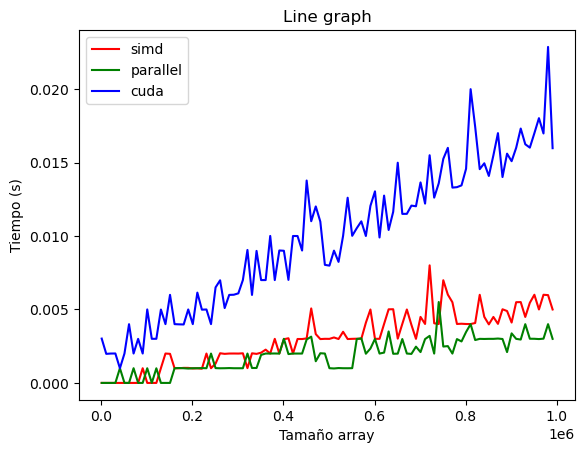

In [71]:
plt.title("Line graph")
plt.xlabel("Tamaño array")
plt.ylabel("Tiempo (s)")
plt.plot(tamaño, simd, color ="red", label="simd")
plt.plot(tamaño, parallel, color ="green", label="parallel")
plt.plot(tamaño, cuda_t, color ="blue", label="cuda")
plt.legend(loc="upper left")
plt.show()

El resultado que obtenemos no es el esperado, pues a priori pensamos que CUDA es lo más eficiente. Pero la realidad es distinta, lo más seguro es que se deba a que el tiempo de transmisión en este problema tan sencillo sea incluso mayor que el tiempo de resolución en las versiones usando la CPU.

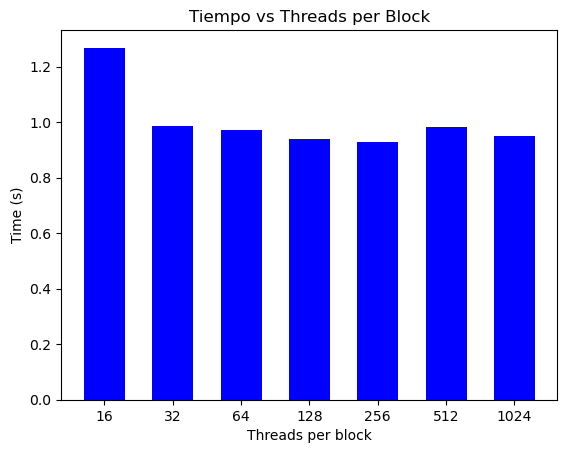

In [76]:
time_threads = []
sizes = [16, 32, 64, 128, 256, 512, 1024]

for i in sizes:
    with Timer() as t:
        for j in range(1000, 1000000, 10000):
            array = np.random.rand(j)
            stencil_1d_cuda(array, radius=3, threadsperblock=i)
            cuda.synchronize()
    time_threads.append(t.interval)

plt.title("Tiempo vs Threads per Block")
plt.xlabel("Threads per block")
plt.ylabel("Time (s)")

x = range(len(sizes))  # [0, 1, 2, 3, 4, 5, 6]
plt.bar(x, time_threads, color="blue", width=0.6)
plt.xticks(x, sizes)   # etiquetas reales en el eje X

plt.show()

Después de repetir el experimento varias veces observamos que posiblemente el tamaño idoneo sean 256 hilos por bloque y afirmando de forma categórica que tienen que ser bloques de más de 16 hilos.